# 06 — LSTM Knowledge Gap Prediction

**Project:** MARS — Multi-Agent Recommender System for Personalized Learning  
**Agent:** PredictionAgent  
**Purpose:** Train the GapPredictionLSTM, evaluate per-tag AUC-ROC,
and generate paper figures (loss curves, PR curves, example predictions).

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
)

plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300,
    "font.size": 11, "axes.titlesize": 13,
    "axes.labelsize": 12, "figure.figsize": (8, 5),
    "savefig.bbox": "tight",
})

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

import logging
logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print("Libraries loaded.")

Device: cpu
Libraries loaded.


## 1. Load Data

In [2]:
from data.loader import EdNetLoader

loader = EdNetLoader(data_dir="../data/raw")
interactions = loader.load_interactions(sample_users=1000)
questions = loader.questions

print(f"Interactions: {len(interactions):,} ({interactions['user_id'].nunique()} users)")
print(f"Questions: {len(questions):,}")
print(f"Columns: {list(interactions.columns)}")

data.loader | Loading questions from ..\data\raw\questions.csv


data.loader | Loaded 13169 questions, 189 unique tags


data.loader | Found 297444 user files in KT2/


data.loader | Quintile 1: 60307 users available, sampled 203 (file size range: 131–861 bytes)


data.loader | Quintile 2: 59141 users available, sampled 199 (file size range: 862–1010 bytes)


...

data.loader | Sampled 1000 / 297444 users (0.3%) — stratified=True


data.loader | Raw KT2 rows: 183166 from 1000 users (load: 2.2s)


data.loader | Aggregating encounters (vectorized)...


data.loader | Final interactions: 51802 rows, 998 users (derive: 0.3s, total: 8.8s)


Interactions: 51,802 (998 users)
Questions: 13,169
Columns: ['user_id', 'timestamp', 'question_id', 'bundle_id', 'part_id', 'tags', 'correct', 'elapsed_time', 'changed_answer', 'response_count', 'source']


In [3]:
# Chronological split: train (70%), val (15%), test (15%)
from data.preprocessor import EdNetPreprocessor

preprocessor = EdNetPreprocessor(
    output_dir="../data/processed",
    splits_dir="../data/splits",
)
# Clean and add features
df_clean = preprocessor.clean(interactions)
df_feat = preprocessor.engineer_features(df_clean)
splits = preprocessor.chronological_split(df_feat)

train_df = splits["train"]
val_df = splits["val"]
test_df = splits["test"]

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

data.preprocessor | Elapsed time filter [1000, 300000]ms: 51802 → 51554 rows (removed 248, 0.5%)


data.preprocessor | Min-answers filter (>=10): 51554 → 48312 rows, 998 → 430 users (removed 568 users, 56.9%)


data.preprocessor | Cleaning summary: 51802 → 48312 rows (93.3% retained), 998 → 430 users (43.1% retained)


data.preprocessor | Feature engineering complete. Columns: ['user_id', 'timestamp', 'question_id', 'bundle_id', 'part_id', 'tags', 'correct', 'elapsed_time', 'changed_answer', 'response_count', 'source', 'tag_accuracy', 'avg_elapsed_by_tag', 'session_id', 'rolling_accuracy', 'time_since_last']


data.preprocessor | Split sizes — train: 33964 (70.3%), val: 7311 (15.1%), test: 7037 (14.6%)


Train: 33,964  Val: 7,311  Test: 7,037


## 2. Build Sequence Datasets

In [4]:
from agents.prediction_agent import (
    PredictionAgent, GapPredictionLSTM, GapSequenceDataset,
    NUM_TAGS, SEQ_LEN, HORIZON, DEVICE,
)
from agents.confidence_agent import ConfidenceAgent
from agents.diagnostic_agent import DiagnosticAgent
from torch.utils.data import DataLoader

# Enrich splits with the confidence labels expected by PredictionAgent
diag = DiagnosticAgent()
irt_params = diag.calibrate_from_interactions(train_df, min_answers_per_q=5)
conf_agent = ConfidenceAgent(n_classes=6)
conf_agent.train(train_df, irt_params=irt_params)

def attach_confidence_classes(df):
    df = df.copy()
    preds = conf_agent.classify_batch(interactions=df)
    df["confidence_class"] = preds["classes"]
    return df

train_df = attach_confidence_classes(train_df)
val_df = attach_confidence_classes(val_df)
test_df = attach_confidence_classes(test_df)

train_dataset = GapSequenceDataset(train_df, seq_len=SEQ_LEN, horizon=HORIZON)
val_dataset = GapSequenceDataset(val_df, seq_len=SEQ_LEN, horizon=HORIZON)
test_dataset = GapSequenceDataset(test_df, seq_len=SEQ_LEN, horizon=HORIZON)

print(f"Train sequences: {len(train_dataset):,}")
print(f"Val sequences:   {len(val_dataset):,}")
print(f"Test sequences:  {len(test_dataset):,}")

# Inspect one sample
x_sample, y_sample = train_dataset[0]
print(f"\nSample input shape: {x_sample.shape}  (seq_len, 6)")
print(f"Sample label shape: {y_sample.shape}  (num_tags,)")
print(f"Sample label — active tags: {y_sample.nonzero().squeeze().tolist()}")

faiss.loader | Loading faiss with AVX2 support.


faiss.loader | Successfully loaded faiss with AVX2 support.


2026-04-02 17:50:47 | mars.agent.diagnostic          | INFO    | Building response matrix: 2274 questions, 429 users


mars.agent.diagnostic | Building response matrix: 2274 questions, 429 users


2026-04-02 17:50:47 | mars.agent.diagnostic          | INFO    | Calibrating IRT 3PL: 429 students x 2274 items


...

2026-04-02 17:50:57 | mars.agent.prediction          | INFO    | Built 2423 sequences (seq_len=50, horizon=10) from 430 users


mars.agent.prediction | Built 2423 sequences (seq_len=50, horizon=10) from 430 users


2026-04-02 17:50:57 | mars.agent.prediction          | INFO    | Built 2406 sequences (seq_len=50, horizon=10) from 430 users


mars.agent.prediction | Built 2406 sequences (seq_len=50, horizon=10) from 430 users


Train sequences: 22,189
Val sequences:   2,423
Test sequences:  2,406

Sample input shape: torch.Size([50, 6])  (seq_len, 6)
Sample label shape: torch.Size([293])  (num_tags,)
Sample label — active tags: [74, 78, 96, 114, 116, 123, 132]


## 3. Train PredictionAgent

In [5]:
agent = PredictionAgent()
metrics = agent.train(train_df, val_df=val_df, epochs=50, batch_size=256, patience=5)

print("\nTraining Results:")
for k, v in metrics.items():
    if k != "history":
        print(f"  {k}: {v}")

2026-04-02 17:50:57 | mars.agent.prediction          | INFO    | Building training sequences...


mars.agent.prediction | Building training sequences...


2026-04-02 17:50:57 | mars.agent.prediction          | INFO    | Built 22189 sequences (seq_len=50, horizon=10) from 430 users


mars.agent.prediction | Built 22189 sequences (seq_len=50, horizon=10) from 430 users


2026-04-02 17:50:57 | mars.agent.prediction          | INFO    | Built 2423 sequences (seq_len=50, horizon=10) from 430 users


...

2026-04-02 18:05:12 | mars.agent.prediction          | INFO    | Early stopping at epoch 11 (best=6, val_loss=0.0729)


mars.agent.prediction | Early stopping at epoch 11 (best=6, val_loss=0.0729)


2026-04-02 18:05:12 | mars.agent.prediction          | INFO    | Training complete: best_epoch=6, val_loss=0.0729, val_auc=0.5193


mars.agent.prediction | Training complete: best_epoch=6, val_loss=0.0729, val_auc=0.5193



Training Results:
  best_epoch: 6
  train_loss: 0.0772
  val_loss: 0.0729
  val_auc: 0.5193
  model_type: lstm
  n_train_sequences: 22189
  n_val_sequences: 2423
  total_epochs: 11


## 4. Training / Validation Loss Curves

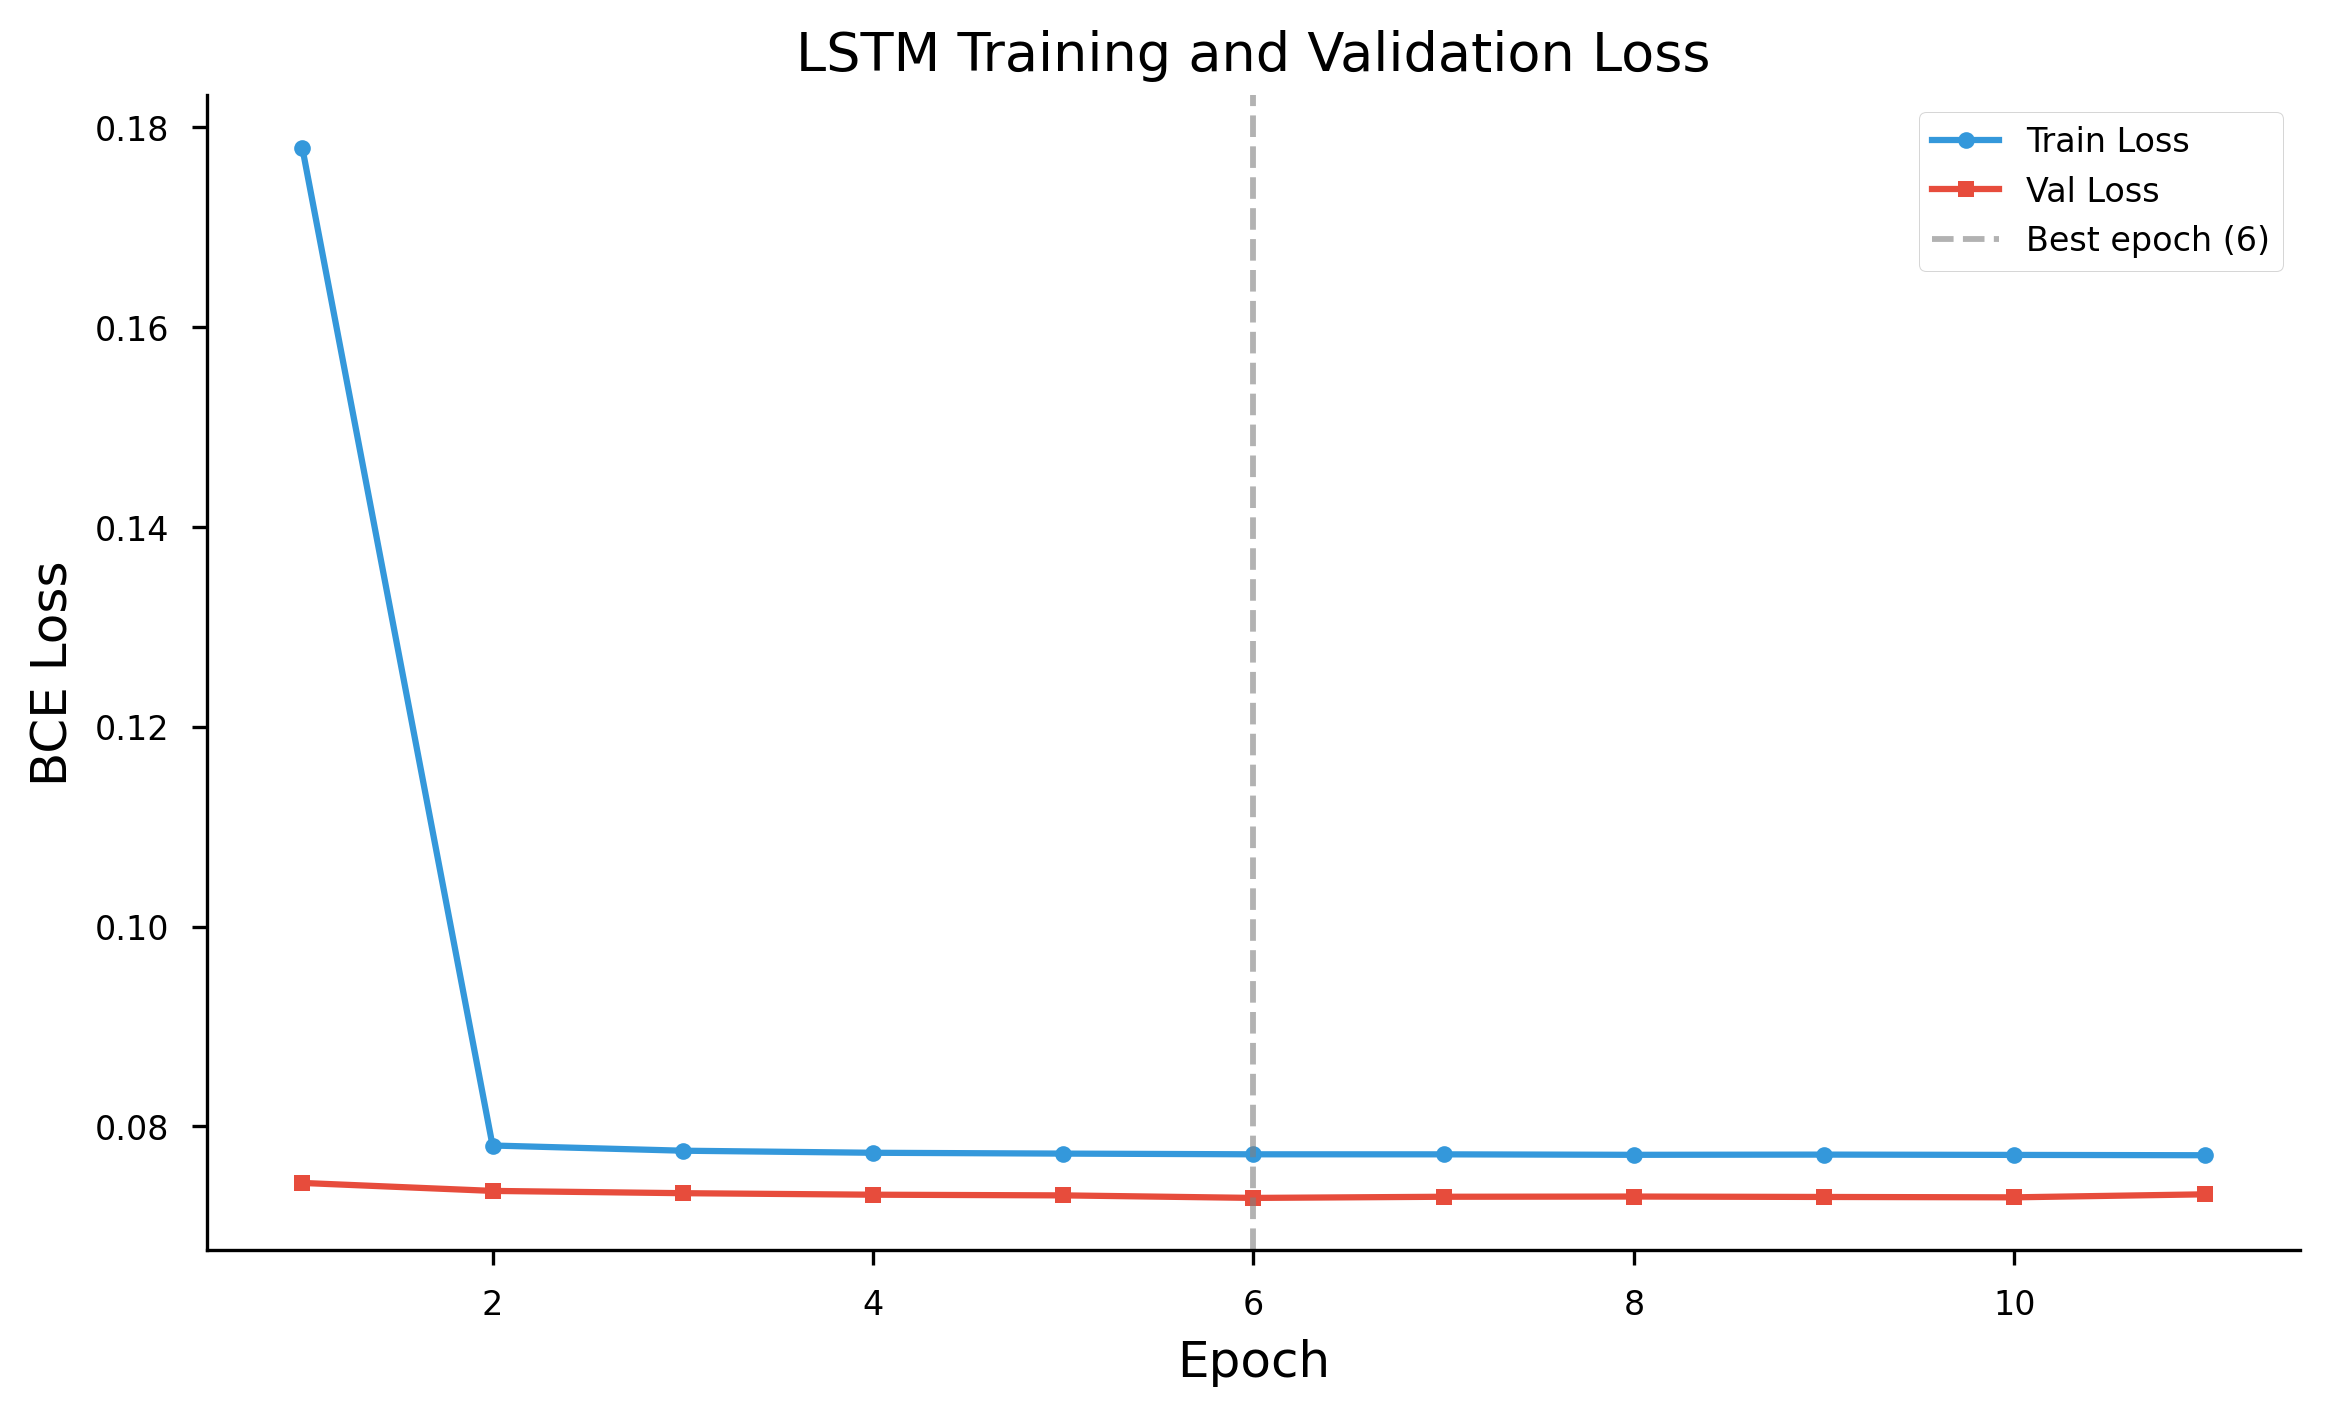

In [6]:
history = metrics["history"]
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs_range, history["train_loss"], "o-", color="#3498db",
        markersize=4, linewidth=1.5, label="Train Loss")
ax.plot(epochs_range, history["val_loss"], "s-", color="#e74c3c",
        markersize=4, linewidth=1.5, label="Val Loss")
ax.axvline(metrics["best_epoch"], color="gray", linestyle="--", alpha=0.6,
           label=f"Best epoch ({metrics['best_epoch']})")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("LSTM Training and Validation Loss")
ax.legend()
sns.despine()

fig.savefig(RESULTS_DIR / "fig_lstm_loss_curves.png")
plt.show()

## 5. Evaluate on Test Set

In [7]:
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

all_preds = []
all_labels = []

agent.model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds = agent.model(X_batch).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y_batch.numpy())

y_true = np.concatenate(all_labels, axis=0)
y_score = np.concatenate(all_preds, axis=0)

print(f"Test samples: {y_true.shape[0]:,}")
print(f"Tags with at least one positive: {(y_true.sum(axis=0) > 0).sum()} / {NUM_TAGS}")
print(f"Average tags failed per sample: {y_true.sum(axis=1).mean():.1f}")

Test samples: 2,406
Tags with at least one positive: 157 / 293
Average tags failed per sample: 5.9


## 6. Per-Tag AUC-ROC (Top-20 and Bottom-20)

Tags with computable AUC: 147 / 293
Mean AUC: 0.5435
Median AUC: 0.5036


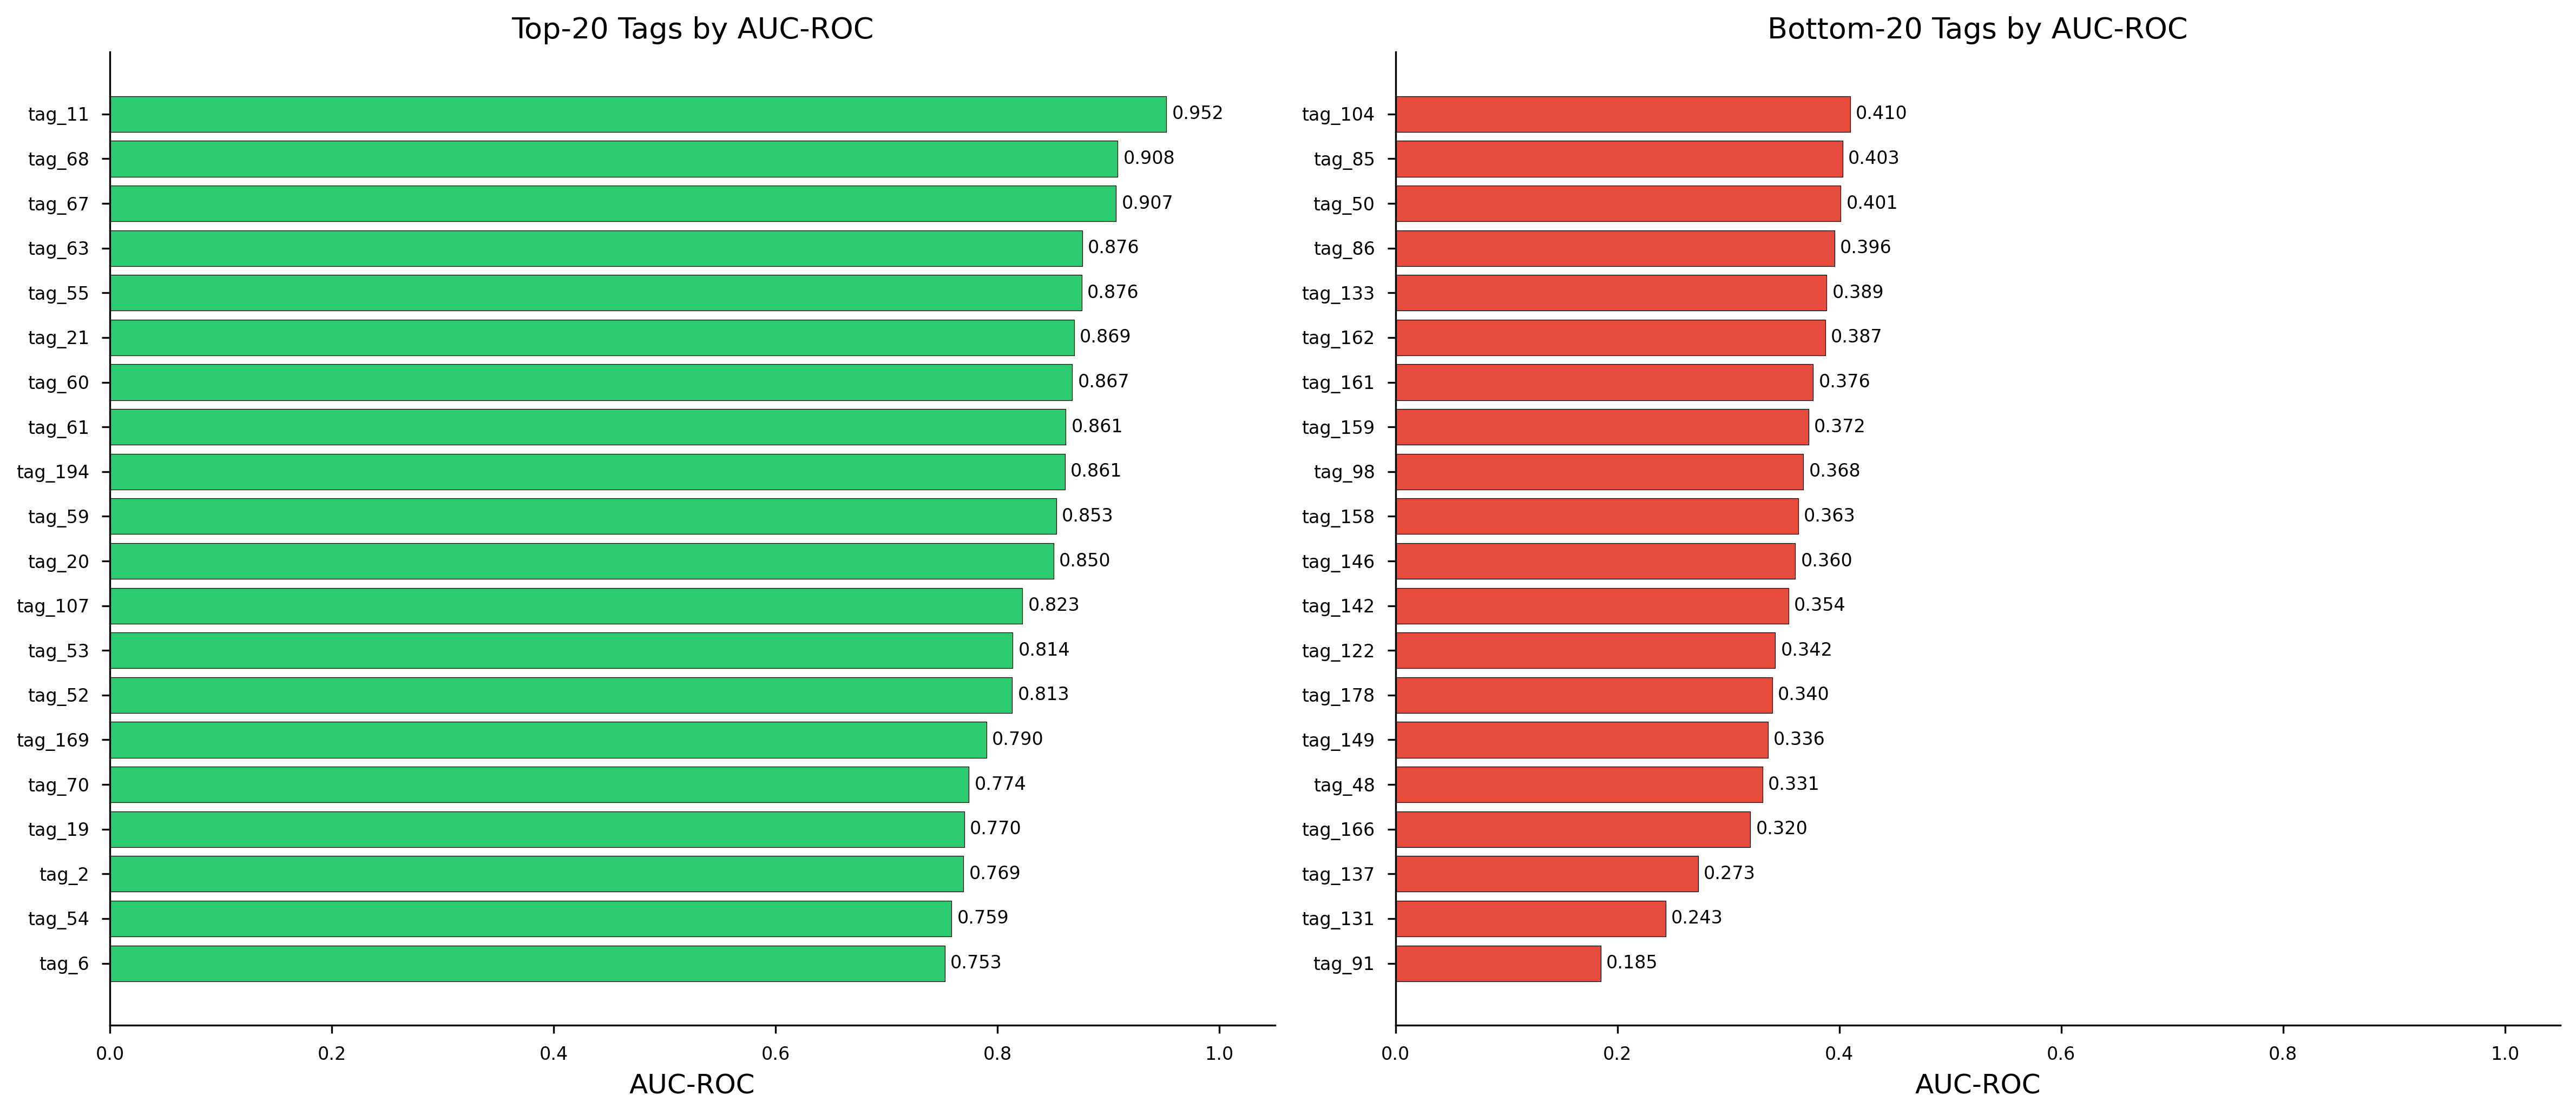

In [8]:
# Compute AUC per tag (only tags with enough positive samples)
tag_aucs = {}
min_positives = 10

for tag_id in range(NUM_TAGS):
    n_pos = y_true[:, tag_id].sum()
    if n_pos >= min_positives:
        try:
            tag_auc = roc_auc_score(y_true[:, tag_id], y_score[:, tag_id])
            tag_aucs[tag_id] = tag_auc
        except ValueError:
            pass

auc_series = pd.Series(tag_aucs).sort_values(ascending=False)
print(f"Tags with computable AUC: {len(auc_series)} / {NUM_TAGS}")
print(f"Mean AUC: {auc_series.mean():.4f}")
print(f"Median AUC: {auc_series.median():.4f}")

# ── Plot top-20 and bottom-20 ──
top20 = auc_series.head(20)
bottom20 = auc_series.tail(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 20
ax = axes[0]
bars = ax.barh(
    [f"tag_{t}" for t in top20.index],
    top20.values,
    color="#2ecc71", edgecolor="black", linewidth=0.3,
)
for bar, val in zip(bars, top20.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)
ax.set_xlabel("AUC-ROC")
ax.set_title("Top-20 Tags by AUC-ROC")
ax.set_xlim(0, 1.05)
ax.invert_yaxis()
sns.despine(ax=ax)

# Bottom 20
ax = axes[1]
bars = ax.barh(
    [f"tag_{t}" for t in bottom20.index],
    bottom20.values,
    color="#e74c3c", edgecolor="black", linewidth=0.3,
)
for bar, val in zip(bars, bottom20.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)
ax.set_xlabel("AUC-ROC")
ax.set_title("Bottom-20 Tags by AUC-ROC")
ax.set_xlim(0, 1.05)
ax.invert_yaxis()
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_lstm_auc_per_tag.png")
plt.show()

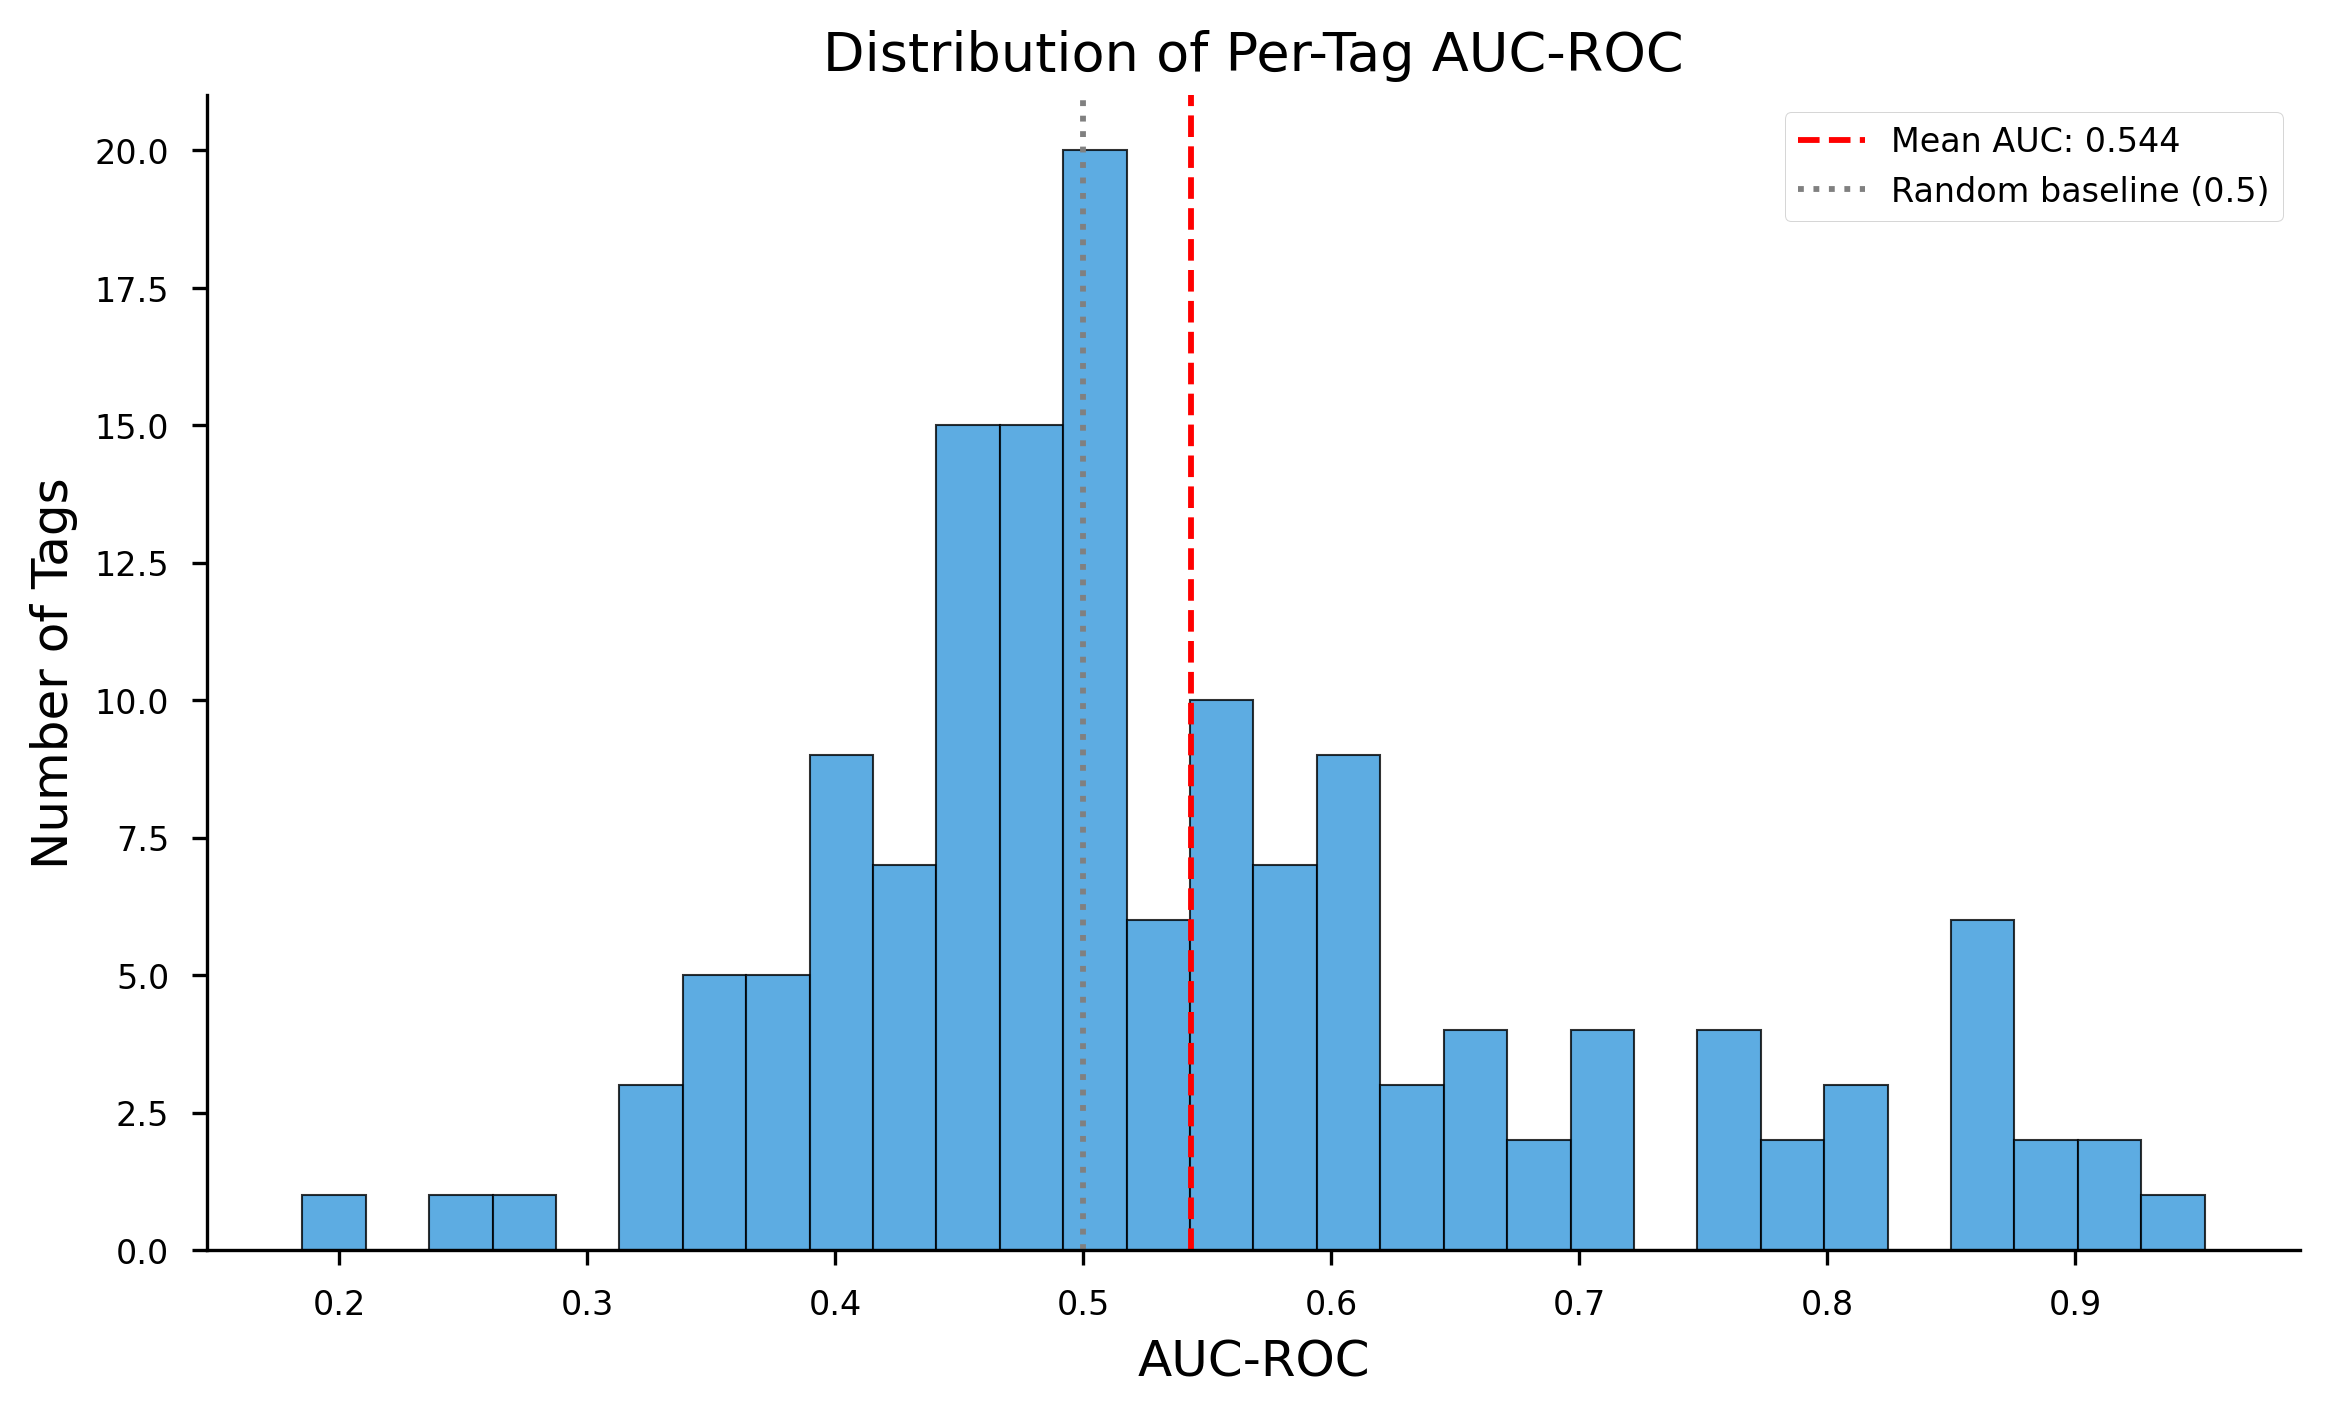

In [9]:
# AUC distribution histogram
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(auc_series.values, bins=30, color="#3498db", edgecolor="black",
        linewidth=0.5, alpha=0.8)
ax.axvline(auc_series.mean(), color="red", linestyle="--",
           label=f"Mean AUC: {auc_series.mean():.3f}")
ax.axvline(0.5, color="gray", linestyle=":", label="Random baseline (0.5)")
ax.set_xlabel("AUC-ROC")
ax.set_ylabel("Number of Tags")
ax.set_title("Distribution of Per-Tag AUC-ROC")
ax.legend()
sns.despine()

fig.savefig(RESULTS_DIR / "fig_lstm_auc_distribution.png")
plt.show()

## 7. Precision-Recall Curve (Micro-Averaged)

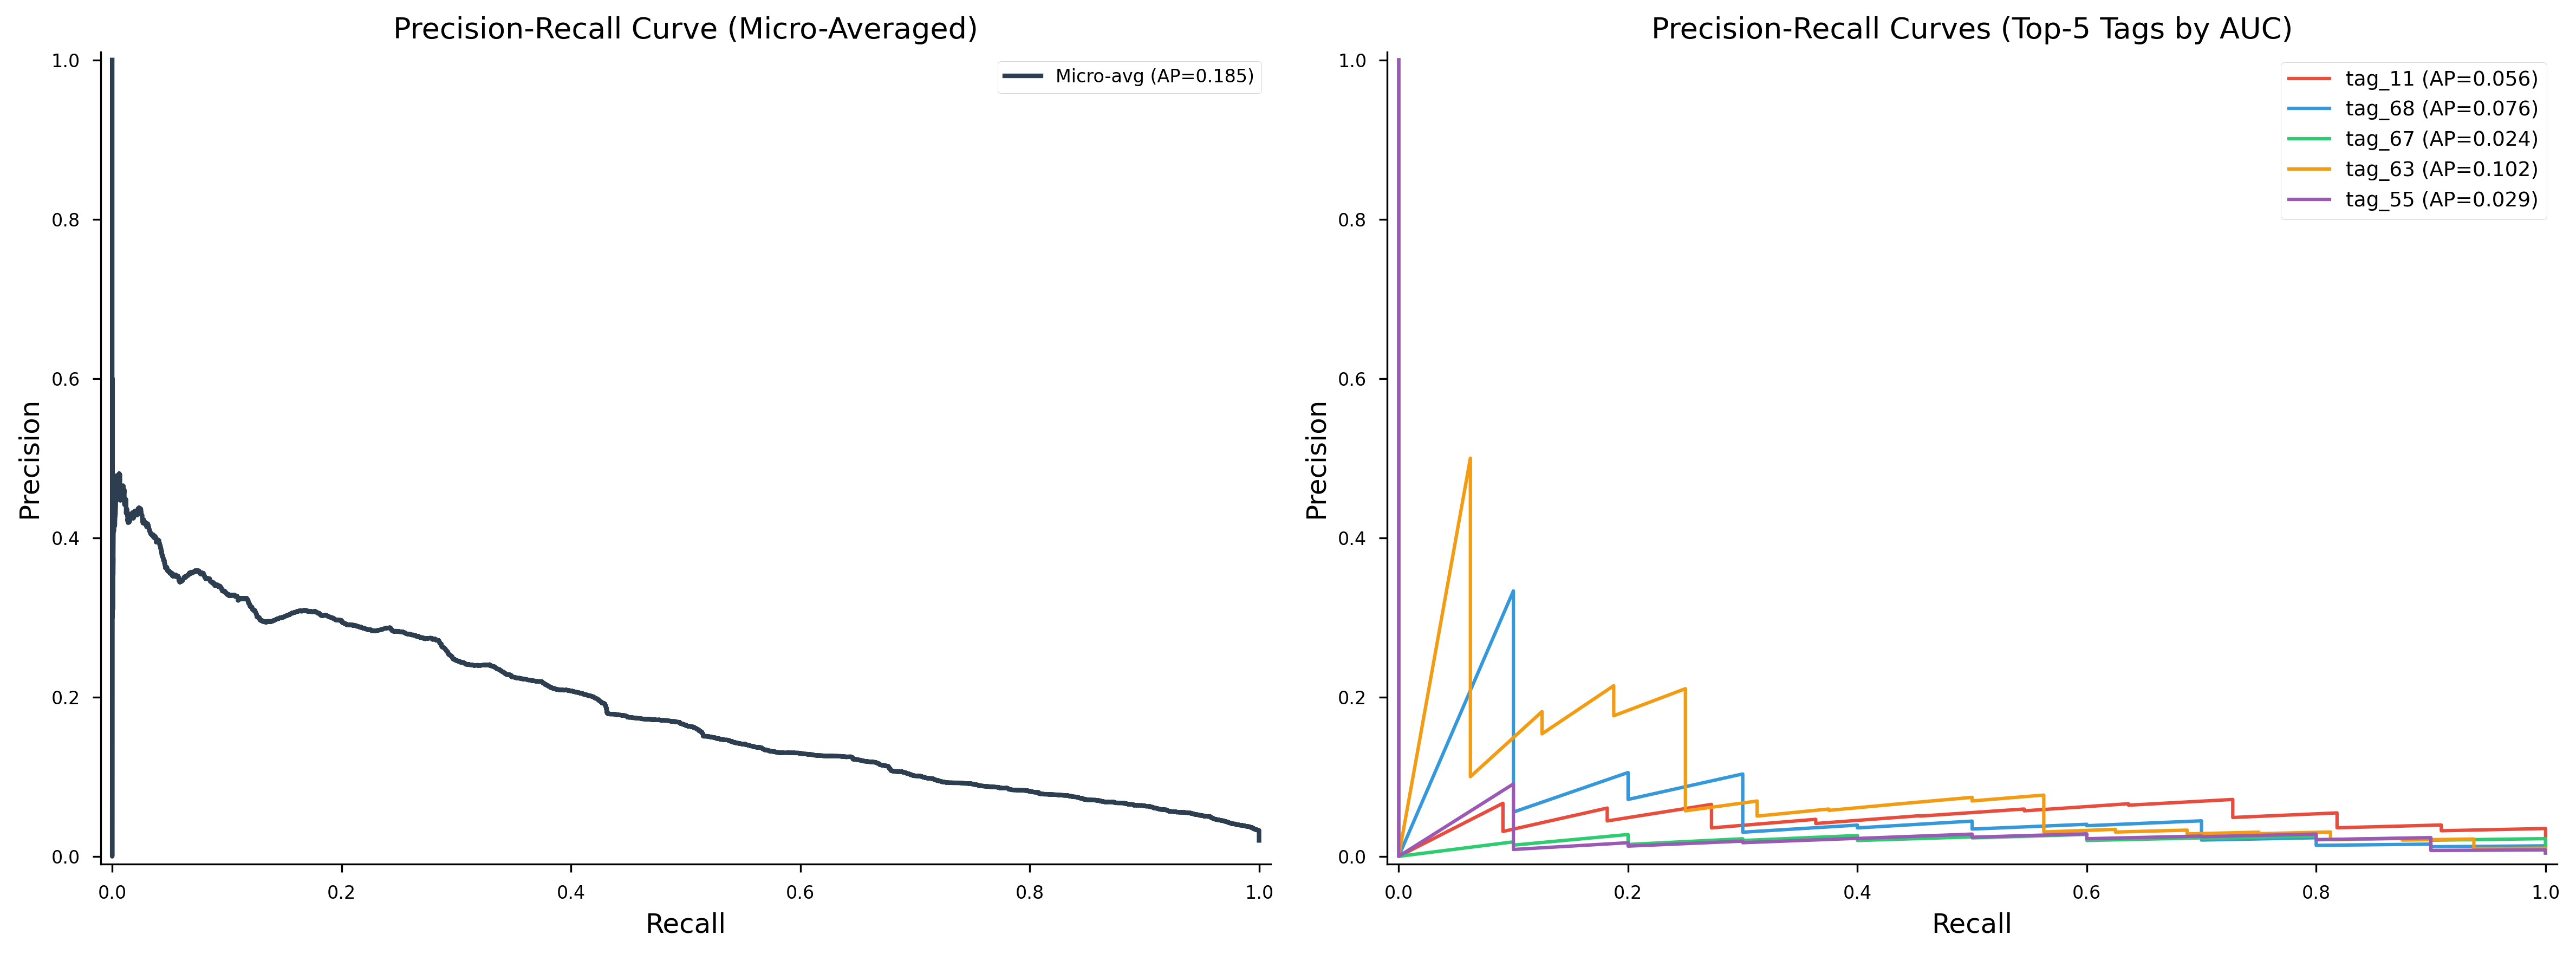

In [10]:
# Micro-averaged P-R curve across all tags
precision_micro, recall_micro, thresholds_pr = precision_recall_curve(
    y_true.ravel(), y_score.ravel(),
)
ap_micro = average_precision_score(y_true.ravel(), y_score.ravel())

# Per-tag P-R curves for top-5 AUC tags
top5_tags = auc_series.head(5).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: micro-averaged
ax = axes[0]
ax.plot(recall_micro, precision_micro, color="#2c3e50", linewidth=2,
        label=f"Micro-avg (AP={ap_micro:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve (Micro-Averaged)")
ax.legend(loc="upper right")
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
sns.despine(ax=ax)

# Right: per-tag for top-5
ax = axes[1]
colors_5 = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]
for tag_id, color in zip(top5_tags, colors_5):
    p, r, _ = precision_recall_curve(y_true[:, tag_id], y_score[:, tag_id])
    ap = average_precision_score(y_true[:, tag_id], y_score[:, tag_id])
    ax.plot(r, p, color=color, linewidth=1.5,
            label=f"tag_{tag_id} (AP={ap:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves (Top-5 Tags by AUC)")
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_lstm_precision_recall.png")
plt.show()

## 8. Example Predictions (5 Students)

In [11]:
# Select 5 students from test set with enough interactions
test_users = test_df.groupby("user_id").size()
eligible = test_users[test_users >= SEQ_LEN + HORIZON].index.tolist()
rng = np.random.RandomState(42)
sample_users = rng.choice(eligible, size=min(5, len(eligible)), replace=False)

print(f"Selected {len(sample_users)} students for example predictions")
print(f"User IDs: {sample_users.tolist()}")

Selected 5 students for example predictions
User IDs: ['u289959', 'u352205', 'u321841', 'u496168', 'u10219']


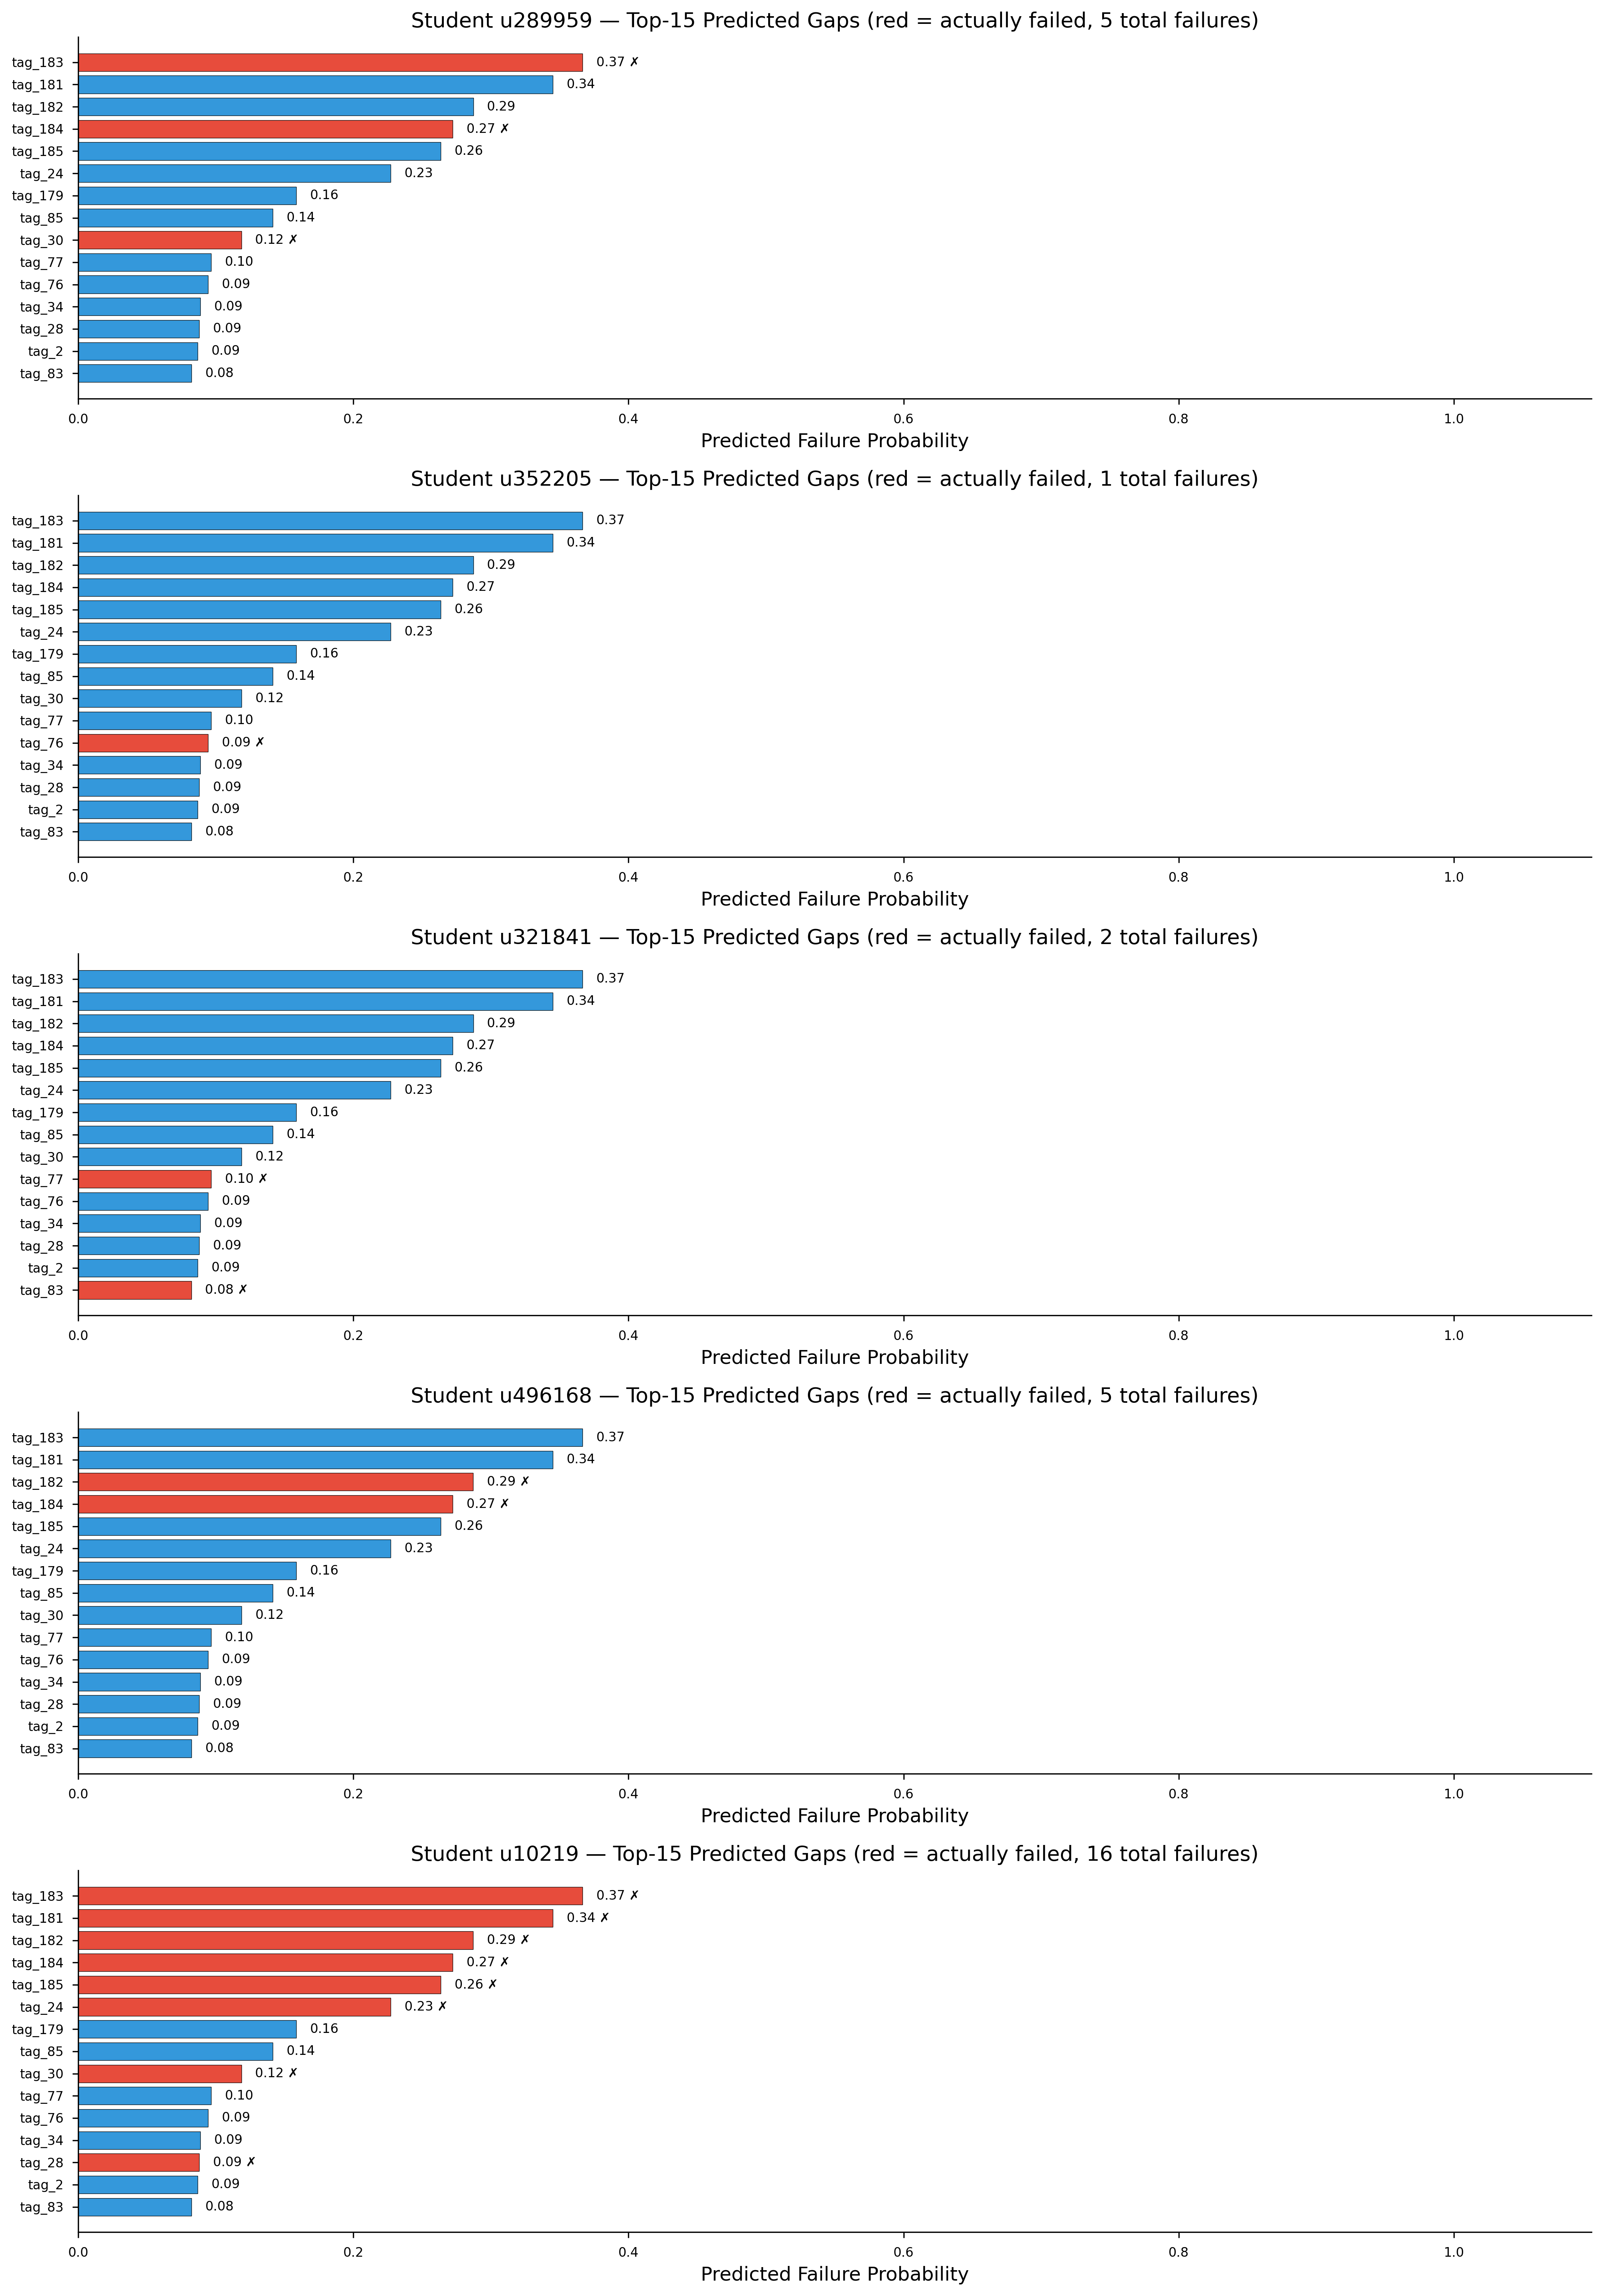

In [12]:
fig, axes = plt.subplots(len(sample_users), 1, figsize=(14, 4 * len(sample_users)))
if len(sample_users) == 1:
    axes = [axes]

for idx, (uid, ax) in enumerate(zip(sample_users, axes)):
    user_df = test_df[test_df["user_id"] == uid].sort_values("timestamp").reset_index(drop=True)

    # Use first SEQ_LEN interactions as input
    context = user_df.iloc[:SEQ_LEN]
    future = user_df.iloc[SEQ_LEN:SEQ_LEN + HORIZON]

    # Predict gaps via agent
    result = agent.predict_gaps(str(uid), recent=context, threshold=0.3)
    pred_probs = np.array(result["gap_probabilities"])

    # Ground truth: which tags were actually failed
    actual_failed = set()
    for _, row in future.iterrows():
        if not row["correct"]:
            tags = row.get("tags", [])
            if isinstance(tags, str):
                tags = [int(t.strip()) for t in tags.replace(";", ",").split(",") if t.strip().isdigit()]
            elif isinstance(tags, list):
                tags = [int(t) for t in tags]
            for t in tags:
                if 0 <= t < NUM_TAGS:
                    actual_failed.add(t)

    # Show top-15 predicted tags
    top_predicted = np.argsort(pred_probs)[-15:][::-1]

    tag_labels = [f"tag_{t}" for t in top_predicted]
    pred_vals = [pred_probs[t] for t in top_predicted]
    bar_colors = ["#e74c3c" if t in actual_failed else "#3498db" for t in top_predicted]

    bars = ax.barh(tag_labels, pred_vals, color=bar_colors,
                   edgecolor="black", linewidth=0.3)

    # Mark actual failures
    for i, t in enumerate(top_predicted):
        marker = " \u2717" if t in actual_failed else ""
        ax.text(pred_vals[i] + 0.01, i, f"{pred_vals[i]:.2f}{marker}",
                va="center", fontsize=8)

    ax.set_xlabel("Predicted Failure Probability")
    ax.set_title(f"Student {uid} — Top-15 Predicted Gaps "
                 f"(red = actually failed, {len(actual_failed)} total failures)")
    ax.set_xlim(0, 1.1)
    ax.invert_yaxis()
    sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_lstm_example_predictions.png")
plt.show()

## 9. Threshold Analysis

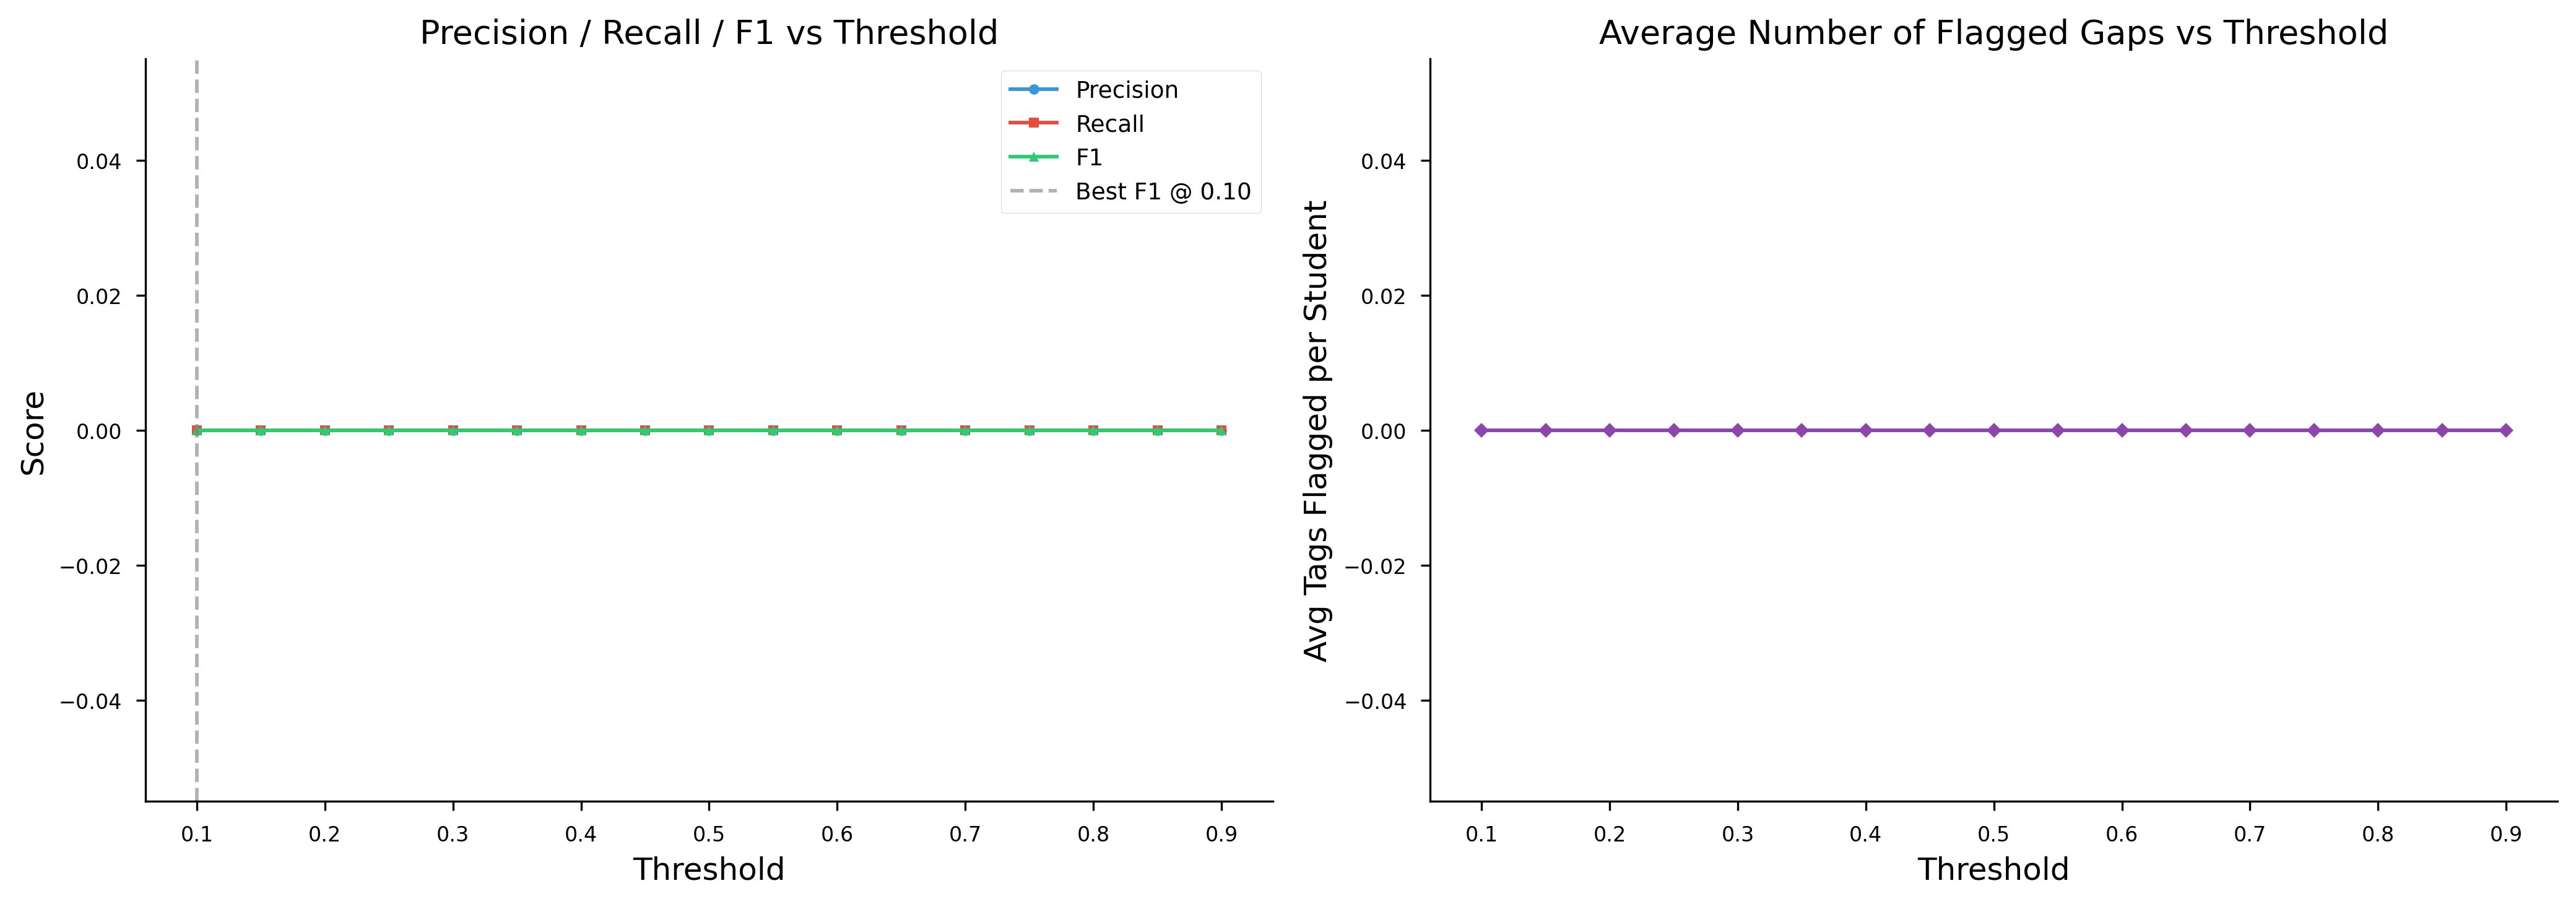


Threshold analysis:
 threshold  precision  recall  f1  avg_gaps_flagged
     0.100          0   0.000   0             0.000
     0.150          0   0.000   0             0.000
     0.200          0   0.000   0             0.000
     0.250          0   0.000   0             0.000
     0.300          0   0.000   0             0.000
     0.350          0   0.000   0             0.000
     0.400          0   0.000   0             0.000
     0.450          0   0.000   0             0.000
     0.500          0   0.000   0             0.000
     0.550          0   0.000   0             0.000
     0.600          0   0.000   0             0.000
     0.650          0   0.000   0             0.000
     0.700          0   0.000   0             0.000
     0.750          0   0.000   0             0.000
     0.800          0   0.000   0             0.000
     0.850          0   0.000   0             0.000
     0.900          0   0.000   0             0.000


In [13]:
# How many gaps are flagged at different thresholds?
thresholds = np.arange(0.1, 0.91, 0.05)
results = []

for thr in thresholds:
    y_pred_bin = (y_score >= thr).astype(int)
    # Micro precision, recall
    tp = (y_pred_bin * y_true).sum()
    fp = (y_pred_bin * (1 - y_true)).sum()
    fn = ((1 - y_pred_bin) * y_true).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    avg_gaps = y_pred_bin.sum(axis=1).mean()
    results.append({
        "threshold": thr,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "avg_gaps_flagged": avg_gaps,
    })

thr_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thr_df["threshold"], thr_df["precision"], "o-", color="#3498db",
        label="Precision", markersize=4)
ax.plot(thr_df["threshold"], thr_df["recall"], "s-", color="#e74c3c",
        label="Recall", markersize=4)
ax.plot(thr_df["threshold"], thr_df["f1"], "^-", color="#2ecc71",
        label="F1", markersize=4)
best_f1_idx = thr_df["f1"].idxmax()
ax.axvline(thr_df.loc[best_f1_idx, "threshold"], color="gray",
           linestyle="--", alpha=0.6,
           label=f"Best F1 @ {thr_df.loc[best_f1_idx, 'threshold']:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold")
ax.legend(fontsize=9)
sns.despine(ax=ax)

ax = axes[1]
ax.plot(thr_df["threshold"], thr_df["avg_gaps_flagged"], "D-",
        color="#8e44ad", markersize=4)
ax.set_xlabel("Threshold")
ax.set_ylabel("Avg Tags Flagged per Student")
ax.set_title("Average Number of Flagged Gaps vs Threshold")
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_lstm_threshold_analysis.png")
plt.show()

print("\nThreshold analysis:")
print(thr_df.to_string(index=False, float_format="%.3f"))

## 10. Agent Integration Test

In [14]:
# Test predict_gaps via the agent API
test_user = sample_users[0] if len(sample_users) > 0 else test_df["user_id"].iloc[0]
user_df = test_df[test_df["user_id"] == test_user].sort_values("timestamp")
recent = user_df.head(SEQ_LEN)

result = agent.predict_gaps(str(test_user), recent=recent, threshold=0.5)
print(f"User: {test_user}")
print(f"Gaps found (threshold=0.5): {result['n_gaps']}")
print("\nTop gaps:")
for g in result["gaps"][:10]:
    print(f"  tag_{g['tag_id']}: {g['probability']:.3f}")

# Test get_at_risk_tags
at_risk = agent.get_at_risk_tags(str(test_user), recent=recent, threshold=0.4)
print(f"\nAt-risk tags (threshold=0.4): {len(at_risk)}")

# Test update_state (continuous pipeline)
interaction = {
    "question_id": 100,
    "tags": [5, 10],
    "correct": False,
    "elapsed_time": 20000,
    "changed_answer": False,
    "part_id": 3,
    "confidence_class": 3,  # CLEAR_GAP
}
state = agent.update_state(str(test_user), interaction)
print(f"\nUpdate state result:")
print(f"  Buffer size: {state['buffer_size']}")
print(f"  At-risk tags: {state['n_at_risk']}")
print(f"  Top risks: {state['top_risks']}")

User: u289959
Gaps found (threshold=0.5): 0

Top gaps:

At-risk tags (threshold=0.4): 0

Update state result:
  Buffer size: 50
  At-risk tags: 0
  Top risks: [{'tag_id': 183, 'probability': 0.3667}, {'tag_id': 181, 'probability': 0.345}, {'tag_id': 182, 'probability': 0.2872}, {'tag_id': 184, 'probability': 0.2723}, {'tag_id': 185, 'probability': 0.2636}]


## 11. Summary Statistics for Paper

In [15]:
# Collect all metrics for the paper table
overall_auc = roc_auc_score(
    y_true[:, y_true.sum(axis=0) > 0],
    y_score[:, y_true.sum(axis=0) > 0],
    average="macro",
)

best_thr = thr_df.loc[thr_df["f1"].idxmax()]

summary = {
    "Model": "GapPredictionLSTM",
    "Input": f"Last {SEQ_LEN} interactions, {6} features each",
    "Output": f"{NUM_TAGS} tags, sigmoid probabilities",
    "Horizon": f"Next {HORIZON} questions",
    "Best Epoch": metrics["best_epoch"],
    "Train Loss (best)": metrics["train_loss"],
    "Val Loss (best)": metrics["val_loss"],
    "Val AUC (during training)": metrics["val_auc"],
    "Test AUC-ROC (macro)": round(overall_auc, 4),
    "Test AP (micro)": round(ap_micro, 4),
    "Mean Per-Tag AUC": round(auc_series.mean(), 4),
    "Median Per-Tag AUC": round(auc_series.median(), 4),
    f"Best Threshold (F1)": round(float(best_thr['threshold']), 2),
    f"Best F1": round(float(best_thr['f1']), 4),
    f"Precision @ best thr": round(float(best_thr['precision']), 4),
    f"Recall @ best thr": round(float(best_thr['recall']), 4),
    "Tags evaluated": len(auc_series),
    "Train sequences": len(train_dataset),
    "Test sequences": len(test_dataset),
}

print("\n" + "=" * 55)
print("  LSTM Gap Prediction — Summary for Paper")
print("=" * 55)
for k, v in summary.items():
    print(f"  {k:30s}: {v}")

# Save to CSV
pd.Series(summary, name="value").to_csv(RESULTS_DIR / "lstm_summary.csv")
print(f"\nSaved summary → {RESULTS_DIR / 'lstm_summary.csv'}")


  LSTM Gap Prediction — Summary for Paper
  Model                         : GapPredictionLSTM
  Input                         : Last 50 interactions, 6 features each
  Output                        : 293 tags, sigmoid probabilities
  Horizon                       : Next 10 questions
  Best Epoch                    : 6
  Train Loss (best)             : 0.0772
  Val Loss (best)               : 0.0729
  Val AUC (during training)     : 0.5193
  Test AUC-ROC (macro)          : 0.5384
  Test AP (micro)               : 0.1851
  Mean Per-Tag AUC              : 0.5435
  Median Per-Tag AUC            : 0.5036
  Best Threshold (F1)           : 0.1
  Best F1                       : 0.0
  Precision @ best thr          : 0.0
  Recall @ best thr             : 0.0
  Tags evaluated                : 147
  Train sequences               : 22189
  Test sequences                : 2406

Saved summary → ..\results\lstm_summary.csv


In [16]:
print("\n=== LSTM Knowledge Gap Prediction Complete ===")
print(f"Model: GapPredictionLSTM (2-layer, hidden={128})")
print(f"Sequence length: {SEQ_LEN}, Horizon: {HORIZON}")
print(f"Test AUC-ROC (macro): {overall_auc:.4f}")
print(f"Figures saved to: {RESULTS_DIR.resolve()}")


=== LSTM Knowledge Gap Prediction Complete ===
Model: GapPredictionLSTM (2-layer, hidden=128)
Sequence length: 50, Horizon: 10
Test AUC-ROC (macro): 0.5384
Figures saved to: C:\Users\user\Documents\Diser\система\ednet-mars\results
